# ICPR 2026 (experiment)

## Data download

Refer to the notebook [`data-download.ipynb`](notebooks/data-download.ipynb) to download the LARD (v.1) dataset. Once downloaded and unzipped (into the `../LARD_dataset` directory by default), you can continue and export the data to YOLO format.

## Data export

Refer to the notebook [`data-export.ipynb`](notebooks/data-export.ipynb) to export the downloaded LARD datasets into proper YOLO format. Once exported, the dataset should be stored in `data/datasets/name_of_exported_datasets` directory.

## YOLO model training

Refer to the notebook [`ml-yolo.ipynb`](notebooks/ml-yolo.ipynb) to train the YOLO model on the exported dataset. Training is done for 10 epochs (not necessary to train longer as the model is quite good at performing this simple runway detection task...).

## Setup

In [1]:
%load_ext skipkernel_extension

In [2]:
should_skip_training_eval = False
should_skip_test_eval_stepbystep = True
should_skip_test_eval_automatics = False

In [3]:
from pathlib import Path

import json
import numpy as np
import torch
import tqdm

# For monitors evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# For YOLO models
from ultralytics import YOLO

# From SwMF package
from swmf.data import create_dataloader
from swmf.data import default_img_transform, default_lab_transform

from swmf.models.yolo_utils import DEFAULT_YOLO_IOU_THRESHOLD
from swmf.models.yolo_utils import DEFAULT_YOLO_OBJ_THRESHOLD
from swmf.models.yolo_utils import postproc_yolo_outputs, postproc_yolo_targets

from swmf.metrics import match_predictions
from swmf.metrics import compute_metrics, compute_safety_metrics

from swmf.monitors.ODD import ODD_GLAC_checker, format_meta_data
from swmf.monitors.OOD import OOD_BetaQuantile
from swmf.monitors.OMS.bam import OMS_BAM_YOLO_logits

In [4]:
### Reproducibility ###
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
#######################

In [5]:
PATH_LARD = "data/datasets/lard_512x512_ICPR2026"
PATH_YOLO = "data/models/detect/yolov5n/lard_512x512_ICPR2026_split_trainval_per_runway/020_epochs/best.pt"

In [6]:
path_to_yolo = Path(PATH_YOLO).resolve()
assert path_to_yolo.exists(), f"ERROR: Specified path does not exist {path_to_yolo}"

path_to_lard = Path(PATH_LARD).resolve()
assert path_to_lard.exists(), f"ERROR: Specified path does not exist {path_to_lard}"

split_fpath = path_to_lard / "split_trainval_per_runway.csv"
split_dname = split_fpath.stem
assert split_fpath.exists(), f"ERROR: Specified path does not exist {split_fpath}"

In [7]:
path_to_results = Path("results").resolve()
path_to_results = path_to_results / PATH_LARD.split('/')[-1] / "detect" / "yolov5n" / (path_to_lard.stem + "_" + split_fpath.stem) / "020_epochs" / split_dname
path_to_results

PosixPath('/home/dariom/Workspace/LARD_monitoring/results/lard_512x512_ICPR2026/detect/yolov5n/lard_512x512_ICPR2026_split_trainval_per_runway/020_epochs/split_trainval_per_runway')

In [13]:
### HYPERPARAMETERS ###
IOU_THRESHOLD = 0.70  # The IOU threshold to evaluate on
#######################

## YOLO model calibration

Create the data loader objects for each dataset (train/valid/test)

In [8]:
IMGSZ = (512, 512)
BATCH = 8

trainval_images_path = path_to_lard / "task_detect" / "images" / "train"
trainval_labels_path = path_to_lard / "task_detect" / "labels" / "train"
trainval_loader = create_dataloader(
    image_dpath=trainval_images_path,
    label_dpath=trainval_labels_path,
    image_transform=default_img_transform(IMGSZ),
    label_transform=default_lab_transform(IMGSZ),
    yolo_task="detect",
    data_mode="train",
    batch_size=BATCH*4,
    shuffle=False,
)

train_loader = create_dataloader(
    dataset_dpath=path_to_lard,
    image_transform=default_img_transform(IMGSZ),
    label_transform=default_lab_transform(IMGSZ),
    yolo_task="detect",
    data_mode="train",
    split_fpath=split_fpath,
    split="train",
    using_metadata=False,
    batch_size=BATCH*4,
    shuffle=False,
)

valid_loader = create_dataloader(
    dataset_dpath=path_to_lard,
    image_transform=default_img_transform(IMGSZ),
    label_transform=default_lab_transform(IMGSZ),
    yolo_task="detect",
    data_mode="train",
    split_fpath=split_fpath,
    split="valid",
    using_metadata=False,
    batch_size=BATCH*4,
    shuffle=False,
)

test_loader = create_dataloader(
    dataset_dpath=path_to_lard,
    image_transform=default_img_transform(IMGSZ),
    label_transform=default_lab_transform(IMGSZ),
    yolo_task="detect",
    data_mode="test",
    using_metadata=True,
    batch_size=BATCH,
    shuffle=False,
)

Path to metadata not provided, trying to infer based on dataset path...
Found existing metadata at /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/task_detect/metadatas/test


In [9]:
yolo_model = YOLO(path_to_yolo)
yolo_model.fuse()
yolo_model.eval();

YOLOv5n summary (fused): 84 layers, 2,503,139 parameters, 0 gradients, 7.1 GFLOPs


In [11]:
ML_KWARGS = {
    'conf': DEFAULT_YOLO_OBJ_THRESHOLD,
    'iou' : DEFAULT_YOLO_IOU_THRESHOLD,
}

In [12]:
y_pred_valid = torch.Tensor([], device='cpu')
y_true_valid = torch.Tensor([], device='cpu')

tmp_imgs_n = 0
for X, y in tqdm.tqdm(valid_loader, desc="[VALID] Predicting..."):
    r = yolo_model.predict(X, verbose=False, **ML_KWARGS)

    y_pred_valid = torch.cat([y_pred_valid, postproc_yolo_outputs(r, imgs_n=tmp_imgs_n)])
    y_true_valid = torch.cat([y_true_valid, postproc_yolo_targets(y, imgs_n=tmp_imgs_n)])
    tmp_imgs_n += len(y)

# Compute and save the optimal confidence threshold
metrics_ml_valid = compute_metrics(y_pred=y_pred_valid, y_true=y_true_valid, iou_thresh=IOU_THRESHOLD)

print()
print("Metrics for YOLO [VALID]", f"(IOU={IOU_THRESHOLD})")
print("========================")
print("\n".join(f"{k} = {v}" for k, v in metrics_ml_valid.items()))
print()

# Optimal t_conf. Shape (n_iou_thresholds)
optimal_conf_threshold = metrics_ml_valid['c']
print("Optimal t_conf =", optimal_conf_threshold)

# Save results
result_path = path_to_results / "metrics" / "valid" / f"IOU_{int(IOU_THRESHOLD*100):03d}"
result_path.mkdir(exist_ok=True, parents=True)
with open(result_path /  f"yolo.json", "w") as f:
    json.dump(metrics_ml_valid, f)

[VALID] Predicting...:   0%|          | 0/46 [00:00<?, ?it/s]

[VALID] Predicting...: 100%|██████████| 46/46 [00:16<00:00,  2.85it/s]



Metrics for YOLO [VALID] (IOU=0.7)
ap = 0.8651633858680725
f1 = 0.8270289897918701
p = 0.8901185989379883
r = 0.772290825843811
c = 0.6951009631156921
tp = 1126.0
fp = 139.0
fn = 332.0
n_p = 1265.0
n_t = 1458.0

Optimal t_conf = 0.6951009631156921


In [14]:
%%skip $should_skip_training_eval

y_pred_train = torch.Tensor([], device='cpu')
y_true_train = torch.Tensor([], device='cpu')

tmp_imgs_n = 0
for X, y in tqdm.tqdm(train_loader, desc="[TRAIN] Predicting..."):
    r = yolo_model.predict(X, verbose=False, **ML_KWARGS)

    y_pred_train = torch.cat([y_pred_train, postproc_yolo_outputs(r, imgs_n=tmp_imgs_n)])
    y_true_train = torch.cat([y_true_train, postproc_yolo_targets(y, imgs_n=tmp_imgs_n)])
    tmp_imgs_n += len(y)

# Compute and save the optimal confidence threshold
metrics_ml_train = compute_metrics(y_pred=y_pred_train, y_true=y_true_train, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold)

print()
print("Metrics for YOLO [TRAIN]", f"(IOU={IOU_THRESHOLD})")
print("========================")
print("\n".join(f"{k} = {v}" for k, v in metrics_ml_train.items()))
print()

# Save results
result_path = path_to_results / "metrics" / "train" / f"IOU_{int(IOU_THRESHOLD*100):03d}"
result_path.mkdir(exist_ok=True, parents=True)
with open(result_path / f"yolo.json", "w") as f:
    json.dump(metrics_ml_train, f)

[TRAIN] Predicting...: 100%|██████████| 201/201 [01:05<00:00,  3.08it/s]



Metrics for YOLO [TRAIN] (IOU=0.7)
ap = 0.9947942495346069
f1 = 0.9869188070297241
p = 0.997133731842041
r = 0.9769110679626465
c = 0.6931145787239075
tp = 6262.0
fp = 18.0
fn = 148.0
n_p = 6280.0
n_t = 6410.0



## Monitors setup and train

In [15]:
### Reproducibility ###
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
#######################

### Setup ODD monitoring

In [16]:
# Define the ODD monitor (GLAC)
odd_monitor = ODD_GLAC_checker()
odd_monitor

### Setup OOD monitoring

In [19]:
# Define the OOD monitor (Beta distributions on image props) and train it
ood_monitor = OOD_BetaQuantile()
ood_monitor.fit(trainval_loader, verbose=True)
ood_monitor

# Calibrate the OOD monitor ?


Fitting Beta distribution on edge_amount : 100%|██████████| 246/246 [00:38<00:00,  6.38it/s]


OOD_BetaQuantile(
 - brightness  : BetaDist(a=31.427; b=26.668; loc=0.00; scale=1.00)
 - saturation  : BetaDist(a=17.117; b=38.913; loc=0.00; scale=1.00)
 - entropy     : BetaDist(a=67.441; b= 6.544; loc=0.00; scale=1.00)
 - edge_amount : BetaDist(a= 6.172; b= 8.129; loc=0.00; scale=1.00)
)

### Setup OMS monitoring

In [20]:
# Define the OMS monitor and train it
oms_monitor = OMS_BAM_YOLO_logits(yolo_model, density="auto")
oms_monitor.fit(train_loader, verbose=True, keep_only_good=True, iou_thresh=IOU_THRESHOLD, iou_method="CIOU")

# # Calibrate the OMS monitor
# oms_y_true_score_valid = np.where(match_predictions(y_pred_valid, y_true_valid, iou_thresh=IOU_THRESHOLD, iou_method="CIOU")[0] != -1, 1, 0)
# oms_y_pred_score_valid = torch.Tensor([], device="cpu")

# for X, y in tqdm.tqdm(valid_loader, desc="[VALID] Predicting..."):
#     oms_y_pred_score_valid = torch.cat([oms_y_pred_score_valid, torch.Tensor(oms_monitor.score_tensor(X, **ML_KWARGS))])

# oms_y_pred_score_valid = oms_y_pred_score_valid.detach().cpu().numpy()
# oms_thresh_score_valid = np.percentile(oms_y_pred_score_valid[oms_y_true_score_valid == 0], 95)

# print(f"OMS monitor threshold score: {oms_thresh_score_valid}")

Fitting monitor parameters...


Finding hyperparameters...: 100%|██████████| 78/78 [00:04<00:00, 17.00it/s]


n_clusters = 19


<div style="text-align: justify">

According to (He et al., 2025), calibration of the OMS monitor using the FPR95 (FPR@TPR=.95). So we need to compute the TPR of the OMS monitor and set its score threshold to when the TPR is at 95%. We derive 2 possible ways of interpretating this step as provided in (He et al., 2025):

- Compute the TPR of the IMS (in-model-scope) data (False Alarm Probability)

$$ \text{TPR}^{[\text{IMS}]} = \frac{num\_accepted\_IMS}{num\_IMS}$$

- Compute the TPR of the OMS (out-of-model-scope) data (Recall)

$$ \text{TPR}^{[\text{OMS}]} = \frac{num\_rejected\_OMS}{num\_OMS}$$

</div>

In [21]:
# Compute the ground truths of the OMS monitor (1=should reject (OMS), 0=should accept(IMS))
oms_true_valid = np.where(match_predictions(y_pred_valid, y_true_valid, iou_thresh=IOU_THRESHOLD)[0] != -1, 0, 1)  # 0 = TP/IMS, 1 = FP/OMS

# COmpute the predictions of the OMS monitor on the valid set
oms_pred_valid = torch.Tensor([])
for X, y in tqdm.tqdm(valid_loader, desc="[VALID] Predicting OMS monitoring scores..."):
    oms_pred_valid = torch.cat([oms_pred_valid, torch.Tensor(oms_monitor.score_tensor(X, **ML_KWARGS))])
oms_pred_valid = oms_pred_valid.detach().cpu().numpy()

# Compute the 95 TPR percentile
ii = np.argsort(oms_pred_valid) # sort oms scores
oms_pred_valid_sorted = oms_pred_valid[ii]
oms_true_valid_sorted = oms_true_valid[ii]

[VALID] Predicting OMS monitoring scores...: 100%|██████████| 46/46 [00:13<00:00,  3.31it/s]


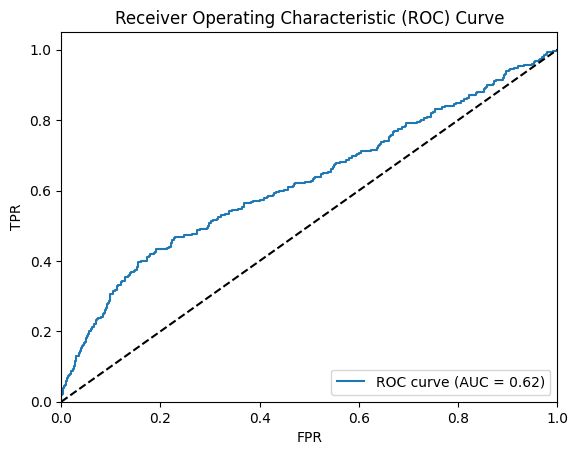

In [22]:
fpr, tpr, thresholds = roc_curve(oms_true_valid, oms_pred_valid)
auc = roc_auc_score(oms_true_valid, oms_pred_valid)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [23]:
# Compute TPR_OMS = 95% (i.e., Recall = 0.95)
tpr_percentile = 0.95

omsc = oms_true_valid_sorted.cumsum()
tpr_oms = omsc / omsc[-1]
oms_score_thresh_tpr95 = oms_pred_valid_sorted[np.argmax(tpr_oms >= tpr_percentile)]
oms_score_thresh_tpr95

np.float32(1.3530629)

In [24]:
# Compute TPR_IMS = 95% (i.e., false alarm proba = 0.05)
fpr_percentile = 0.05

imsc = (1 - oms_true_valid_sorted).cumsum()
tpr_ims = imsc / imsc[-1]
oms_score_thresh_fpr05 = oms_pred_valid_sorted[np.argmax(tpr_ims >= 1 - fpr_percentile)]
oms_score_thresh_fpr05

np.float32(1.1112428)

<div style="text-align: justify">

For the remainder of the experiment, we use the score threshold computed at TPR_IMS=95%

</div>

## Evaluation [TEST]

In [25]:
### Reproducibility ###
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
#######################

### Step-by-step evaluation

Run the model and monitors on every image of the test dataset

In [27]:
%%skip $should_skip_test_eval_stepbystep

# Create the output arrays to store the results
odd_y_pred_mask = torch.Tensor([], device="cpu")
ood_y_pred_mask = torch.Tensor([], device="cpu")
oms_y_pred_mask = torch.Tensor([], device="cpu")

y_pred = torch.Tensor([], device="cpu")
y_true = torch.Tensor([], device="cpu")
metadata = np.empty((0, 9))

# Run inference and store results
imgs_n = 0
for X, y, m in tqdm.tqdm(test_loader, desc="[TEST] Predicting..."):
    r = yolo_model.predict(X, verbose=False, **ML_KWARGS)

    ## Save YOLO predictions
    y_pred = torch.cat([y_pred, postproc_yolo_outputs(r, imgs_n=imgs_n)])
    y_true = torch.cat([y_true, postproc_yolo_targets(y, imgs_n=imgs_n)])
    imgs_n += len(y)

    ## Save metadata
    metadata = np.concatenate([metadata, np.stack(m, axis=0)], axis=0)
    ## ODD monitoring
    odd_y_pred_mask = torch.cat([odd_y_pred_mask, torch.Tensor(odd_monitor.predict(format_meta_data(m)))])
    ## OOD monitoring
    ood_y_pred_mask = torch.cat([ood_y_pred_mask, torch.Tensor(ood_monitor.predict(X))])
    ## OMS monitoring
    oms_y_pred_mask = torch.cat([oms_y_pred_mask, torch.Tensor(oms_monitor.score_tensor(X, **ML_KWARGS))])

# Show results
print(f"Num images: {imgs_n}")
print(f"ML preds [shape = {y_pred.shape}]")
print(f"ML GTs   [shape = {y_true.shape}]")
print(f"Metadata [shape = {metadata.shape}]")

print(f"ODD monitor output shape: {odd_y_pred_mask.shape}")
print(f"OOD monitor output shape: {ood_y_pred_mask.shape}")
print(f"OMS monitor output shape: {oms_y_pred_mask.shape}")

#### Get ODD decision (in terms of images)

In [28]:
%%skip $should_skip_test_eval_stepbystep

## Derive ML predictions after ODD monitoring
id_odd_img_rejected = torch.arange(odd_y_pred_mask.size(dim=0))[odd_y_pred_mask.to(bool)].to(int)

# Get the predictions and targets filtered (only keep in ODD)
y_pred_odd_accepted = y_pred[~torch.isin(y_pred[:, 0], id_odd_img_rejected)]
y_true_odd_accepted = y_true[~torch.isin(y_true[:, 0], id_odd_img_rejected)]

print(f"id_odd_img_rejected: {id_odd_img_rejected.shape}")
print(f"y_pred_odd_accepted: {y_pred_odd_accepted.shape}")
print(f"y_true_odd_accepted: {y_true_odd_accepted.shape}")

#### Get OOD decision (in terms of images)

In [29]:
%%skip $should_skip_test_eval_stepbystep

## Derive ML predictions after OOD monitoring
id_ood_img_rejected = torch.arange(ood_y_pred_mask.size(dim=0))[ood_y_pred_mask.to(bool)].to(int)

# Get the predictions and targets filtered (keep non OOD)
y_pred_ood_accepted = y_pred[~torch.isin(y_pred[:, 0], id_ood_img_rejected)]
y_true_ood_accepted = y_true[~torch.isin(y_true[:, 0], id_ood_img_rejected)]

print(f"id_ood_img_rejected: {id_ood_img_rejected.shape}")
print(f"y_pred_ood_accepted: {y_pred_ood_accepted.shape}")
print(f"y_true_ood_accepted: {y_true_ood_accepted.shape}")

#### Get OMS decision

In [30]:
%%skip $should_skip_test_eval_stepbystep

# Get the ids of the rejected images (at least one rejected pred)
id_oms_img_rejected = torch.unique(y_pred[:, 0][oms_y_pred_mask >= oms_score_thresh_fpr05])

# Get into binary array
oms_binary_mask_over_images = np.isin(np.arange(imgs_n), id_oms_img_rejected)

# Get filtered preds and trues
y_pred_oms_accepted = y_pred[~torch.isin(y_pred[:, 0], id_oms_img_rejected)]
y_true_oms_accepted = y_true[~torch.isin(y_true[:, 0], id_oms_img_rejected)]

print(f"id_oms_img_rejected: {id_oms_img_rejected.shape}")
print(f"y_pred_oms_accepted: {y_pred_oms_accepted.shape}")
print(f"y_true_oms_accepted: {y_true_oms_accepted.shape}")

#### Compute metrics of ML object detection

First, compute for no monitors and single monitors

In [31]:
%%skip $should_skip_test_eval_stepbystep

## YOLO model alone metrics
metrics_ml_test = compute_metrics(y_pred, y_true, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold, return_agg=False)

print("Metrics for YOLO model alone.", f"[IOU={IOU_THRESHOLD}]")
print("========================")
print(" | ".join(f"{k} = {v[0][0]}" for k, v in metrics_ml_test.items()))
print()

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "yolo.json", "w") as f:
    json.dump(metrics_ml_test, f)

## YOLO + ODD monitor
metrics_ml_test_ODD = compute_metrics(y_pred_odd_accepted, y_true_odd_accepted, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold, return_agg=False)

print("Metrics for YOLO model + ODD monitor.", f"[IOU={IOU_THRESHOLD}]")
print("========================")
print(" | ".join(f"{k} = {v[0][0]}" for k, v in metrics_ml_test_ODD.items()))
print()

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "yolo_ODD.json", "w") as f:
    json.dump(metrics_ml_test_ODD, f)

## YOLO + OOD monitor
metrics_ml_test_OOD = compute_metrics(y_pred_ood_accepted, y_true_ood_accepted, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold, return_agg=False)

print("Metrics for YOLO model + OOD monitor.", f"[IOU={IOU_THRESHOLD}]")
print("========================")
print(" | ".join(f"{k} = {v[0][0]}" for k, v in metrics_ml_test_OOD.items()))
print()

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "yolo_OOD.json", "w") as f:
    json.dump(metrics_ml_test_OOD, f)

## YOLO + ODD monitor
metrics_ml_test_OMS = compute_metrics(y_pred_oms_accepted, y_true_oms_accepted, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold, return_agg=False)

print("Metrics for YOLO model + OMS monitor.", f"[IOU={IOU_THRESHOLD}]")
print("========================")
print(" | ".join(f"{k} = {v[0][0]}" for k, v in metrics_ml_test_OMS.items()))
print()

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "yolo_OMS.json", "w") as f:
    json.dump(metrics_ml_test_OMS, f)

Then, compute for combinations of monitors

In [32]:
%%skip $should_skip_test_eval_stepbystep

odd_ood_decision_over_imgs = np.max([odd_y_pred_mask, ood_y_pred_mask], axis=0)
odd_oms_decision_over_imgs = np.max([odd_y_pred_mask, oms_binary_mask_over_images], axis=0)
ood_oms_decision_over_imgs = np.max([ood_y_pred_mask, oms_binary_mask_over_images], axis=0)
all_mon_decision_over_imgs = np.max([odd_y_pred_mask, ood_y_pred_mask, oms_binary_mask_over_images], axis=0)

## Derive ML predictions after ODD+OOD monitoring
id_odd_ood_img_rejected = torch.arange(odd_ood_decision_over_imgs.size)[odd_ood_decision_over_imgs.astype(bool)].to(int)
# Get the predictions and targets filtered (only keep in ODD)
y_pred_odd_ood_accepted = y_pred[~torch.isin(y_pred[:, 0], id_odd_ood_img_rejected)]
y_true_odd_ood_accepted = y_true[~torch.isin(y_true[:, 0], id_odd_ood_img_rejected)]


## Derive ML predictions after ODD+OMS monitoring
id_odd_oms_img_rejected = torch.arange(odd_oms_decision_over_imgs.size)[odd_oms_decision_over_imgs.astype(bool)].to(int)
# Get the predictions and targets filtered (only keep in ODD)
y_pred_odd_oms_accepted = y_pred[~torch.isin(y_pred[:, 0], id_odd_oms_img_rejected)]
y_true_odd_oms_accepted = y_true[~torch.isin(y_true[:, 0], id_odd_oms_img_rejected)]


## Derive ML predictions after OOD+OMS monitoring
id_ood_oms_img_rejected = torch.arange(ood_oms_decision_over_imgs.size)[ood_oms_decision_over_imgs.astype(bool)].to(int)
# Get the predictions and targets filtered (only keep in ODD)
y_pred_ood_oms_accepted = y_pred[~torch.isin(y_pred[:, 0], id_ood_oms_img_rejected)]
y_true_ood_oms_accepted = y_true[~torch.isin(y_true[:, 0], id_ood_oms_img_rejected)]


## Derive ML predictions after ODD+OOD+OMS monitoring
id_all_mon_img_rejected = torch.arange(all_mon_decision_over_imgs.size)[all_mon_decision_over_imgs.astype(bool)].to(int)
# Get the predictions and targets filtered (only keep in ODD)
y_pred_all_mon_accepted = y_pred[~torch.isin(y_pred[:, 0], id_all_mon_img_rejected)]
y_true_all_mon_accepted = y_true[~torch.isin(y_true[:, 0], id_all_mon_img_rejected)]

In [33]:
%%skip $should_skip_test_eval_stepbystep

# ODD + OOD
metrics_ml_test_ODD_OOD = compute_metrics(y_pred_odd_ood_accepted, y_true_odd_ood_accepted, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold, return_agg=False)
print("Metrics for ODD + OOD", f"[IOU={IOU_THRESHOLD}]")
print("========================")
print(" | ".join(f"{k} = {v[0][0]}" for k, v in metrics_ml_test_ODD_OOD.items()))
print()

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "yolo_ODD-OOD.json", "w") as f:
    json.dump(metrics_ml_test_ODD_OOD, f)

# ODD + OMS
metrics_ml_test_ODD_OMS = compute_metrics(y_pred_odd_oms_accepted, y_true_odd_oms_accepted, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold, return_agg=False)
print("Metrics for ODD + OMS", f"[IOU={IOU_THRESHOLD}]")
print("========================")
print(" | ".join(f"{k} = {v[0][0]}" for k, v in metrics_ml_test_ODD_OMS.items()))
print()

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "yolo_ODD-OMS.json", "w") as f:
    json.dump(metrics_ml_test_ODD_OMS, f)

# OOD + OMS
metrics_ml_test_OOD_OMS = compute_metrics(y_pred_ood_oms_accepted, y_true_ood_oms_accepted, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold, return_agg=False)
print("Metrics for OOD + OMS", f"[IOU={IOU_THRESHOLD}]")
print("========================")
print(" | ".join(f"{k} = {v[0][0]}" for k, v in metrics_ml_test_OOD_OMS.items()))
print()

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "yolo_OOD-OMS.json".json", "w") as f:
    json.dump(metrics_ml_test_OOD_OMS, f)

# ODD + OOD + OMS
metrics_ml_test_all_mon = compute_metrics(y_pred_all_mon_accepted, y_true_all_mon_accepted, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold, return_agg=False)
print("Metrics for ODD + OOD + OMS", f"[IOU={IOU_THRESHOLD}]")
print("========================")
print(" | ".join(f"{k} = {v[0][0]}" for k, v in metrics_ml_test_all_mon.items()))
print()

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "yolo_ODD-OOD-OMS.json", "w") as f:
    json.dump(metrics_ml_test_all_mon, f)

#### Compute safety metrics

Compute and save safety metrics for single monitors

In [34]:
%%skip $should_skip_test_eval_stepbystep

## Safety metrics for ODD monitor
safety_metrics_ODD = compute_safety_metrics(y_pred=y_pred, y_true=y_true, monitor_rejects=odd_y_pred_mask, iou_thresh=IOU_THRESHOLD)

print("Safety metrics for ODD monitor.", f"[IOU={IOU_THRESHOLD}]")
print(" | ".join(f"{k} = {v}" for k, v in safety_metrics_ODD.items()))
print()

## Safety metrics for OOD monitor
safety_metrics_OOD = compute_safety_metrics(y_pred=y_pred, y_true=y_true, monitor_rejects=ood_y_pred_mask, iou_thresh=IOU_THRESHOLD)

print("Safety metrics for OOD monitor.", f"[IOU={IOU_THRESHOLD}]")
print(" | ".join(f"{k} = {v}" for k, v in safety_metrics_OOD.items()))
print()

## Safety metrics for ODD monitor
safety_metrics_OMS = compute_safety_metrics(y_pred=y_pred, y_true=y_true, monitor_rejects=oms_binary_mask_over_images, iou_thresh=IOU_THRESHOLD)

print("Safety metrics for OMS monitor.", f"[IOU={IOU_THRESHOLD}]")
print(" | ".join(f"{k} = {v}" for k, v in safety_metrics_OMS.items()))
print()

Compute and save safety metrics for combinations

In [35]:
%%skip $should_skip_test_eval_stepbystep

# ODD + OOD
safety_metrics_ODD_OOD = compute_safety_metrics(y_pred, y_true, odd_ood_decision_over_imgs, iou_thresh=IOU_THRESHOLD)

print("Safety metrics for ODD+OOD monitor.", f"[IOU={IOU_THRESHOLD}]")
print(" | ".join(f"{k} = {v}" for k, v in safety_metrics_ODD_OOD.items()))
print()

# ODD + OMS
safety_metrics_ODD_OMS = compute_safety_metrics(y_pred, y_true, odd_oms_decision_over_imgs, iou_thresh=IOU_THRESHOLD)

print("Safety metrics for ODD+OMS monitor.", f"[IOU={IOU_THRESHOLD}]")
print(" | ".join(f"{k} = {v}" for k, v in safety_metrics_ODD_OMS.items()))
print()

# OOD + OMS
safety_metrics_OOD_OMS = compute_safety_metrics(y_pred, y_true, ood_oms_decision_over_imgs, iou_thresh=IOU_THRESHOLD)

print("Safety metrics for OOD+OMS monitor.", f"[IOU={IOU_THRESHOLD}]")
print(" | ".join(f"{k} = {v}" for k, v in safety_metrics_OOD_OMS.items()))
print()

#all monitors
safety_metrics_all_mon = compute_safety_metrics(y_pred, y_true, all_mon_decision_over_imgs, iou_thresh=IOU_THRESHOLD)

print("Safety metrics for ODD+OOD+OMS monitor.", f"[IOU={IOU_THRESHOLD}]")
print(" | ".join(f"{k} = {v}" for k, v in safety_metrics_all_mon.items()))
print()

Save all metrics into a file

In [36]:
%%skip $should_skip_test_eval_stepbystep

safety_metrics_dict = {
    'ODD': safety_metrics_ODD,
    'OOD': safety_metrics_OOD,
    'OMS': safety_metrics_OMS,
    'ODD-OOD': safety_metrics_ODD_OOD,
    'ODD-OMS': safety_metrics_ODD_OMS,
    'OOD-OMS': safety_metrics_OOD_OMS,
    'ODD-OOD-OMS': safety_metrics_all_mon
}

with open(path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "safety_metrics.json", "w") as f:
    json.dump(safety_metrics_dict, f)

### Auto loop evaluation

In [37]:
# Create the output arrays to store the results
odd_y_pred_mask = torch.Tensor([], device="cpu")
ood_y_pred_mask = torch.Tensor([], device="cpu")
oms_y_pred_mask = torch.Tensor([], device="cpu")

y_pred = torch.Tensor([], device="cpu")
y_true = torch.Tensor([], device="cpu")
metadata = np.empty((0, 9))

# Run inference and store results
imgs_n = 0
for X, y, m in tqdm.tqdm(test_loader, desc="[TEST] Predicting..."):
    r = yolo_model.predict(X, verbose=False, **ML_KWARGS)
    ## Save YOLO predictions
    y_pred = torch.cat([y_pred, postproc_yolo_outputs(r, imgs_n=imgs_n)])
    y_true = torch.cat([y_true, postproc_yolo_targets(y, imgs_n=imgs_n)])
    imgs_n += len(y)
    ## Save metadata
    metadata = np.concatenate([metadata, np.stack(m, axis=0)], axis=0)
    ## ODD monitoring
    odd_y_pred_mask = torch.cat([odd_y_pred_mask, torch.Tensor(odd_monitor.predict(format_meta_data(m)))])
    ## OOD monitoring
    ood_y_pred_mask = torch.cat([ood_y_pred_mask, torch.Tensor(ood_monitor.predict(X))])
    ## OMS monitoring
    oms_y_pred_mask = torch.cat([oms_y_pred_mask, torch.Tensor(oms_monitor.score_tensor(X, **ML_KWARGS))])

## Derive ML predictions after ODD monitoring
id_odd_img_rejected = torch.arange(odd_y_pred_mask.size(dim=0))[odd_y_pred_mask.to(bool)].to(int)

## Derive ML predictions after OOD monitoring
id_ood_img_rejected = torch.arange(ood_y_pred_mask.size(dim=0))[ood_y_pred_mask.to(bool)].to(int)

# Get the ids of the rejected images (at least one rejected pred)
id_oms_img_rejected = torch.unique(y_pred[:, 0][oms_y_pred_mask >= oms_score_thresh_fpr05])
# Get it into binary array
oms_binary_mask_over_images = np.isin(np.arange(imgs_n), id_oms_img_rejected)

# Gather all monitors decision into a dictionary
monitor_rejects_imgs_idx = {
    'ODD': id_odd_img_rejected,
    'OOD': id_ood_img_rejected,
    'OMS': id_oms_img_rejected,
    'ODD-OOD': torch.unique(torch.cat((id_odd_img_rejected, id_ood_img_rejected), dim=0)),
    'ODD-OMS': torch.unique(torch.cat((id_odd_img_rejected, id_oms_img_rejected), dim=0)),
    'OOD-OMS': torch.unique(torch.cat((id_ood_img_rejected, id_oms_img_rejected), dim=0)),
    'ODD-OOD-OMS': torch.unique(torch.cat((id_odd_img_rejected, id_ood_img_rejected, id_oms_img_rejected), dim=0))
}

monitor_rejects_imgs_msk = {
    'ODD': odd_y_pred_mask,
    'OOD': ood_y_pred_mask,
    'OMS': torch.Tensor(oms_binary_mask_over_images),
    'ODD-OOD': torch.Tensor(np.max([odd_y_pred_mask, ood_y_pred_mask], axis=0)),
    'ODD-OMS': torch.Tensor(np.max([odd_y_pred_mask, oms_binary_mask_over_images], axis=0)),
    'OOD-OMS': torch.Tensor(np.max([ood_y_pred_mask, oms_binary_mask_over_images], axis=0)),
    'ODD-OOD-OMS': torch.Tensor(np.max([odd_y_pred_mask, ood_y_pred_mask, oms_binary_mask_over_images], axis=0)),
}

# Compute y_pred and y_true on decisions
print("Computing accepted y_preds and y_trues...")
y_preds_accepted = {}
y_trues_accepted = {}
for mon_id in monitor_rejects_imgs_msk.keys():
    y_preds_accepted[mon_id] = y_pred[~torch.isin(y_pred[:, 0], monitor_rejects_imgs_idx[mon_id])]
    y_trues_accepted[mon_id] = y_true[~torch.isin(y_true[:, 0], monitor_rejects_imgs_idx[mon_id])]

objdet_metrics_dict = {}
safety_metrics_dict = {}

# Compute metrics
print("Computing metrics...")
for mon_id in monitor_rejects_imgs_msk.keys():
    objdet_metrics_dict[mon_id] = compute_metrics(y_preds_accepted[mon_id], y_trues_accepted[mon_id], iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold)

objdet_metrics_dict['yolov5-n'] = compute_metrics(y_pred, y_true, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold)

# Compute safety metrics
print("Computing safety metrics...")
for mon_id in monitor_rejects_imgs_msk.keys():
    safety_metrics_dict[mon_id] = compute_safety_metrics(y_pred, y_true, monitor_rejects_imgs_msk[mon_id], iou_thresh=IOU_THRESHOLD)

# Save to file
result_path = path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}"
result_path.mkdir(exist_ok=True, parents=True)
with open(result_path / "ml_od_metrics_all.json", "w") as f:
    json.dump(objdet_metrics_dict, f)
with open(result_path / "safety_metrics_all.json", "w") as f:
    json.dump(safety_metrics_dict, f)

print(objdet_metrics_dict)

[TEST] Predicting...: 100%|██████████| 277/277 [00:49<00:00,  5.65it/s]


Computing accepted y_preds and y_trues...
Computing metrics...
Computing safety metrics...
{'ODD': {'ap': 0.8625286221504211, 'f1': 0.8291082382202148, 'p': 0.8720200657844543, 'r': 0.7902216911315918, 'c': 0.6948626637458801, 'tp': 1390.0, 'fp': 204.0, 'fn': 369.0, 'n_p': 1594.0, 'n_t': 1759.0}, 'OOD': {'ap': 0.8527327179908752, 'f1': 0.8216598033905029, 'p': 0.8686994314193726, 'r': 0.7794528007507324, 'c': 0.6948626637458801, 'tp': 1396.0, 'fp': 211.0, 'fn': 395.0, 'n_p': 1607.0, 'n_t': 1791.0}, 'OMS': {'ap': 0.8663895726203918, 'f1': 0.836286723613739, 'p': 0.8763858079910278, 'r': 0.7996965050697327, 'c': 0.6948626637458801, 'tp': 1581.0, 'fp': 223.0, 'fn': 396.0, 'n_p': 1804.0, 'n_t': 1977.0}, 'ODD-OOD': {'ap': 0.85797518491745, 'f1': 0.8251186609268188, 'p': 0.8692307472229004, 'r': 0.7852675318717957, 'c': 0.6948626637458801, 'tp': 1130.0, 'fp': 170.0, 'fn': 309.0, 'n_p': 1300.0, 'n_t': 1439.0}, 'ODD-OMS': {'ap': 0.8717215061187744, 'f1': 0.8415229320526123, 'p': 0.877800405025

In [38]:
# Get the complementarity
ODD_npy = monitor_rejects_imgs_msk['ODD'].detach().cpu().numpy()
OOD_npy = monitor_rejects_imgs_msk['OOD'].detach().cpu().numpy()
OMS_npy = monitor_rejects_imgs_msk['OMS'].detach().cpu().numpy()

print("Total image number:", ODD_npy.shape[0])

# Unique ODD
print("Contribution ODD (cumul):", ODD_npy.astype(int).sum())

# Unique OOD
unique_OOD = np.logical_and(OOD_npy, np.logical_not(ODD_npy))
print("Contribution OOD (cumul):", unique_OOD.sum(), "-- and total:", OOD_npy.astype(int).sum())

# Unique OMS
unique_OMS = np.logical_and(OMS_npy, np.logical_not(np.logical_or(ODD_npy, OOD_npy)))
print("Contribution OMS (cumul):", unique_OMS.sum(), "-- and total:", OMS_npy.astype(int).sum())

print("Total image filtered (1):", ODD_npy.astype(int).sum() + unique_OOD.sum() + unique_OMS.sum())
print("Total image filtered (2):", monitor_rejects_imgs_msk['ODD-OOD-OMS'].detach().cpu().numpy().astype(int).sum())

print(monitor_rejects_imgs_msk['ODD-OOD-OMS'].detach().cpu().numpy().astype(int).sum() / ODD_npy.shape[0])


Total image number: 2212
Contribution ODD (cumul): 453
Contribution OOD (cumul): 320 -- and total: 421
Contribution OMS (cumul): 130 -- and total: 235
Total image filtered (1): 903
Total image filtered (2): 903
0.40822784810126583


In [111]:
# import matplotlib.pyplot as plt

# # Define the sections for the first metric (actual values)
# metric1_sections = [
#     (0, 0.05, 'lightblue', 'Section A1'),
#     (0.05, 0.15, 'lightgreen', 'Section A2'),
#     (0.15, 0.25, 'salmon', 'Section A3')
# ]

# # Define the sections for the second metric (actual values)
# metric2_sections = [
#     (0, 0.1, 'lightgray', 'Section B1'),
#     (0.1, 0.3, 'lightcoral', 'Section B2'),
#     (0.3, 0.5, 'lightseagreen', 'Section B3')
# ]

# fig, ax = plt.subplots(figsize=(8, 3))  # Adjusted figure height

# # Function to normalize and plot sections
# def plot_metric(sections, y_pos, ax, bar_height=0.2):
#     total = sections[-1][1]  # Total length of the metric
#     for start, end, color, label in sections:
#         # Normalize to 0-1 range
#         norm_start = start / total
#         norm_end = end / total
#         ax.barh(
#             y=y_pos,
#             left=norm_start,
#             width=norm_end - norm_start,
#             color=color,
#             edgecolor='black',
#             height=bar_height  # Reduced bar height
#         )
#         # Add label in the middle of the section
#         ax.text(
#             (norm_start + norm_end) / 2,
#             y_pos,
#             label,
#             ha='center',
#             va='center',
#             color='black'
#         )

# # Plot the first metric (top bar)
# plot_metric(metric1_sections, y_pos=0.7, ax=ax, bar_height=0.2)

# # Plot the second metric (bottom bar)
# plot_metric(metric2_sections, y_pos=0.3, ax=ax, bar_height=0.2)

# # Customize the plot
# ax.set_ylim(0, 1)  # Adjust y-axis limits
# ax.set_yticks([0.3, 0.7])  # Adjust y-tick positions
# ax.set_yticklabels(['Metric 2', 'Metric 1'])
# ax.set_xlim(0, 1)  # Show x-axis from 0 to 1
# ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Show x-axis ticks
# ax.set_xlabel('Normalized Proportion')  # Label for x-axis
# ax.grid(axis='x', linestyle='--', alpha=0.7)  # Optional: Add grid lines

# plt.tight_layout()
# plt.show()


## YOLO + monitors evaluation (TEST_CORRUPT)

In [39]:
### Reproducibility ###
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
#######################

In [40]:
CORRUPTION_SEVERITIES = [1, 2, 3] 
CORRUPTION_NAMES = [
    'Brightness',
    'Gaussian_Noise',
    'Defocus_Blur',
    'Frosted_Blur',
    'Fog',
]

In [41]:
objdet_metrics_corrupt_dict = {}
safety_metrics_corrupt_dict = {}

for corruption in CORRUPTION_NAMES:
    objdet_metrics_corrupt_dict[corruption] = {}
    safety_metrics_corrupt_dict[corruption] = {}

    for severity in CORRUPTION_SEVERITIES:
        objdet_metrics_corrupt_dict[corruption][severity] = {}
        safety_metrics_corrupt_dict[corruption][severity] = {}

        print(f"Running for CORRUPTION={corruption}, SEVERITY={severity}")

        # Define the data loader for given corruption and severity
        image_dpath = path_to_lard / "images/test_corrupt" / f"{corruption}_severity_{severity}"
        label_dpath = path_to_lard / "task_detect/labels/test"
        test_corruption_loader = create_dataloader(
            image_dpath=image_dpath,
            label_dpath=label_dpath,
            image_transform=default_img_transform(IMGSZ),
            label_transform=default_lab_transform(IMGSZ),
            yolo_task="detect",
            data_mode="test",
            using_metadata=True,
            batch_size=BATCH,
            shuffle=False,
        )

        # Create the output arrays to store the results
        odd_y_pred_mask_corrupt = torch.Tensor([], device="cpu")
        ood_y_pred_mask_corrupt = torch.Tensor([], device="cpu")
        oms_y_pred_mask_corrupt = torch.Tensor([], device="cpu")

        y_pred_corrupt = torch.Tensor([], device="cpu")
        y_true_corrupt = torch.Tensor([], device="cpu")
        metadata_corrupt = np.empty((0, 9))

        # Run inference and store results
        imgs_n = 0
        for X, y, m in tqdm.tqdm(test_corruption_loader, desc=f"[TEST] Predicting ({corruption}-{severity})..."):
            r = yolo_model.predict(X, verbose=False, **ML_KWARGS)
            ## Save YOLO predictions
            y_pred_corrupt = torch.cat([y_pred_corrupt, postproc_yolo_outputs(r, imgs_n=imgs_n)])
            y_true_corrupt = torch.cat([y_true_corrupt, postproc_yolo_targets(y, imgs_n=imgs_n)])
            imgs_n += len(y)
            ## Save metadata
            metadata_corrupt = np.concatenate([metadata_corrupt, np.stack(m, axis=0)], axis=0)
            ## ODD monitoring
            odd_y_pred_mask_corrupt = torch.cat([odd_y_pred_mask_corrupt, torch.Tensor(odd_monitor.predict(format_meta_data(m)))])
            ## OOD monitoring
            ood_y_pred_mask_corrupt = torch.cat([ood_y_pred_mask_corrupt, torch.Tensor(ood_monitor.predict(X))])
            ## OMS monitoring
            oms_y_pred_mask_corrupt = torch.cat([oms_y_pred_mask_corrupt, torch.Tensor(oms_monitor.score_tensor(X, **ML_KWARGS))])

        # ODD monitoring
        id_odd_img_rejected_corrupt = torch.arange(odd_y_pred_mask_corrupt.size(dim=0))[odd_y_pred_mask_corrupt.to(bool)].to(int)
        # OOD monitoring
        id_ood_img_rejected_corrupt = torch.arange(ood_y_pred_mask_corrupt.size(dim=0))[ood_y_pred_mask_corrupt.to(bool)].to(int)
        # OMS monitor
        id_oms_img_rejected_corrupt = torch.unique(y_pred_corrupt[:, 0][oms_y_pred_mask_corrupt >= oms_score_thresh_fpr05])
        oms_binary_mask_over_images_corrupt = np.isin(np.arange(imgs_n), id_oms_img_rejected_corrupt)

        # Store monitors decisions
        monitor_rejects_imgs_idx_corrupt = {
            'ODD': id_odd_img_rejected_corrupt,
            'OOD': id_ood_img_rejected_corrupt,
            'OMS': id_oms_img_rejected_corrupt,
            'ODD-OOD': torch.unique(torch.cat([id_odd_img_rejected_corrupt, id_ood_img_rejected_corrupt], dim=0)),
            'ODD-OMS': torch.unique(torch.cat([id_odd_img_rejected_corrupt, id_oms_img_rejected_corrupt], dim=0)),
            'OOD-OMS': torch.unique(torch.cat([id_ood_img_rejected_corrupt, id_oms_img_rejected_corrupt], dim=0)),
            'ODD-OOD-OMS': torch.unique(torch.cat([id_odd_img_rejected_corrupt, id_ood_img_rejected_corrupt, id_oms_img_rejected_corrupt], dim=0)),
        }


        monitor_rejects_imgs_msk_corrupt = {
            'ODD': odd_y_pred_mask_corrupt,
            'OOD': ood_y_pred_mask_corrupt,
            'OMS': torch.Tensor(oms_binary_mask_over_images_corrupt),
            'ODD-OOD': torch.Tensor(np.max([odd_y_pred_mask_corrupt, ood_y_pred_mask_corrupt], axis=0)),
            'ODD-OMS': torch.Tensor(np.max([odd_y_pred_mask_corrupt, oms_binary_mask_over_images_corrupt], axis=0)),
            'OOD-OMS': torch.Tensor(np.max([ood_y_pred_mask_corrupt, oms_binary_mask_over_images_corrupt], axis=0)),
            'ODD-OOD-OMS': torch.Tensor(np.max([odd_y_pred_mask_corrupt, ood_y_pred_mask_corrupt, oms_binary_mask_over_images_corrupt], axis=0)),
        }

        # Compute y_pred and y_true on decisions
        print("Computing accepted preds and trues")
        y_preds_accepted_corrupt = {}
        y_trues_accepted_corrupt = {}
        for mon_id in monitor_rejects_imgs_msk_corrupt.keys():
            y_preds_accepted_corrupt[mon_id] = y_pred_corrupt[~torch.isin(y_pred_corrupt[:, 0], monitor_rejects_imgs_idx_corrupt[mon_id])]
            y_trues_accepted_corrupt[mon_id] = y_true_corrupt[~torch.isin(y_true_corrupt[:, 0], monitor_rejects_imgs_idx_corrupt[mon_id])]

        # Compute metrics
        print("Computing metrics")
        for mon_id in monitor_rejects_imgs_msk_corrupt.keys():
            objdet_metrics_corrupt_dict[corruption][severity][mon_id] = compute_metrics(y_preds_accepted_corrupt[mon_id], y_trues_accepted_corrupt[mon_id], iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold)
        
        objdet_metrics_corrupt_dict[corruption][severity]['yolov5-n'] = compute_metrics(y_pred_corrupt, y_true_corrupt, iou_thresh=IOU_THRESHOLD, t_conf=optimal_conf_threshold)

        # Compute safety metrics
        print("Computing safety metrics")
        for mon_id in monitor_rejects_imgs_msk_corrupt.keys():
            safety_metrics_corrupt_dict[corruption][severity][mon_id] = compute_safety_metrics(y_pred_corrupt, y_true_corrupt, monitor_rejects_imgs_msk_corrupt[mon_id], iou_thresh=IOU_THRESHOLD)
        
        # Save to file
        result_path = path_to_results / "metrics" / "corrupt" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / f"{corruption}_severity_{severity}"
        result_path.mkdir(exist_ok=True, parents=True)
        with open(result_path / "ml_od_metrics.json", "w") as f:
            json.dump(objdet_metrics_corrupt_dict[corruption][severity], f)
        with open(result_path / "safety_metrics.json", "w") as f:
            json.dump(safety_metrics_corrupt_dict[corruption][severity], f)

Running for CORRUPTION=Brightness, SEVERITY=1
Path to metadata not provided, trying to infer based on dataset path...
Found existing metadata at /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/task_detect/metadatas/test


[TEST] Predicting (Brightness-1)...:   0%|          | 0/277 [00:00<?, ?it/s]

[TEST] Predicting (Brightness-1)...: 100%|██████████| 277/277 [00:45<00:00,  6.07it/s]


Computing accepted preds and trues
Computing metrics
Computing safety metrics
Running for CORRUPTION=Brightness, SEVERITY=2
Path to metadata not provided, trying to infer based on dataset path...
Found existing metadata at /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/task_detect/metadatas/test


[TEST] Predicting (Brightness-2)...: 100%|██████████| 277/277 [00:42<00:00,  6.50it/s]


...

Computing accepted preds and trues
Computing metrics
Computing safety metrics
Running for CORRUPTION=Fog, SEVERITY=2
Path to metadata not provided, trying to infer based on dataset path...
Found existing metadata at /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/task_detect/metadatas/test


[TEST] Predicting (Fog-2)...: 100%|██████████| 277/277 [00:38<00:00,  7.17it/s]


Computing accepted preds and trues
Computing metrics
Computing safety metrics
Running for CORRUPTION=Fog, SEVERITY=3
Path to metadata not provided, trying to infer based on dataset path...
Found existing metadata at /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/task_detect/metadatas/test


[TEST] Predicting (Fog-3)...: 100%|██████████| 277/277 [00:41<00:00,  6.63it/s]


Computing accepted preds and trues
Computing metrics
Computing safety metrics


In [42]:
result_path = path_to_results / "metrics" / "corrupt" / f"IOU_{int(IOU_THRESHOLD*100):03d}"

with open(result_path / f"all_ml_od_metrics.json", "w") as f:
    json.dump(objdet_metrics_corrupt_dict, f)
with open(result_path / f"all_safety_metrics.json", "w") as f:
    json.dump(safety_metrics_corrupt_dict, f)

## Analysis

### Setup

In [43]:
from pathlib import Path
import pandas as pd

PATH_LARD = "data/datasets/lard_512x512_ICPR2026"
PATH_YOLO = "data/models/detect/yolov5n/lard_512x512_ICPR2026_split_trainval_per_runway/020_epochs/best.pt"

path_to_yolo = Path(PATH_YOLO).resolve()
assert path_to_yolo.exists(), f"ERROR: Specified path does not exist {path_to_yolo}"

path_to_lard = Path(PATH_LARD).resolve()
assert path_to_lard.exists(), f"ERROR: Specified path does not exist {path_to_lard}"

split_fpath = path_to_lard / "split_trainval_per_runway.csv"
split_dname = split_fpath.stem
assert split_fpath.exists(), f"ERROR: Specified path does not exist {split_fpath}"

path_to_results = Path("results").resolve()
path_to_results = path_to_results / PATH_LARD.split('/')[-1] / "detect" / "yolov5n" / (path_to_lard.stem + "_" + split_fpath.stem) / "020_epochs" / split_dname
path_to_results

IOU_THRESHOLD = 0.70  # The IOU threshold to evaluate on

### Analysis of standard metrics (on nominal TEST set)

In [44]:
objdet_metrics_test_path = path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "ml_od_metrics_all.json"

objdet_metrics_test_df = pd.read_json(objdet_metrics_test_path, orient="index")
display(objdet_metrics_test_df)

,ap,f1,p,r,c,tp,fp,fn,n_p,n_t
ODD,0.862529,0.829108,0.872020,0.790222,0.694863,1390,204,369,1594,1759
OOD,0.852733,0.821660,0.868699,0.779453,0.694863,1396,211,395,1607,1791
OMS,0.866390,0.836287,0.876386,0.799697,0.694863,1581,223,396,1804,1977
ODD-OOD,0.857975,0.825119,0.869231,0.785268,0.694863,1130,170,309,1300,1439
ODD-OMS,0.871722,0.841523,0.877800,0.808125,0.694863,1293,180,307,1473,1600
OOD-OMS,0.863472,0.835394,0.877049,0.797516,0.694863,1284,180,326,1464,1610
ODD-OOD-OMS,0.867930,0.838915,0.877398,0.803667,0.694863,1052,147,257,1199,1309
yolov5-n,0.855046,0.822381,0.868712,0.780741,0.694863,1727,261,485,1988,2212


In [45]:
column_to_export = ['p', 'r', 'tp', 'fp', 'fn', 'n_p', 'n_t']

# Export as string to place in LateX file
print(objdet_metrics_test_df.to_latex(
    float_format="%.3f",
    columns=column_to_export,
    column_format="c|"+"c"*len(column_to_export)+"",
    caption="Caption",
    label="tab:standard-metrics-test",
    position="t",
))

\begin{table}[t]
\caption{Caption}
\label{tab:standard-metrics-test}
\begin{tabular}{c|ccccccc}
\toprule
 & p & r & tp & fp & fn & n_p & n_t \\
\midrule
ODD & 0.872 & 0.790 & 1390 & 204 & 369 & 1594 & 1759 \\
OOD & 0.869 & 0.779 & 1396 & 211 & 395 & 1607 & 1791 \\
OMS & 0.876 & 0.800 & 1581 & 223 & 396 & 1804 & 1977 \\
ODD-OOD & 0.869 & 0.785 & 1130 & 170 & 309 & 1300 & 1439 \\
ODD-OMS & 0.878 & 0.808 & 1293 & 180 & 307 & 1473 & 1600 \\
OOD-OMS & 0.877 & 0.798 & 1284 & 180 & 326 & 1464 & 1610 \\
ODD-OOD-OMS & 0.877 & 0.804 & 1052 & 147 & 257 & 1199 & 1309 \\
yolov5-n & 0.869 & 0.781 & 1727 & 261 & 485 & 1988 & 2212 \\
\bottomrule
\end{tabular}
\end{table}



### Analysis of safety metrics (on nominal TEST set)

In [46]:
safety_metrics_test_path = path_to_results / "metrics" / "test" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "safety_metrics_all.json"

safety_metrics_test_df = pd.read_json(safety_metrics_test_path, orient="index")
display(safety_metrics_test_df)

,SG,RH,AC
ODD,0.046112,0.155515,0.158680
OOD,0.040687,0.160940,0.149638
OMS,0.039783,0.161844,0.066456
ODD-OOD,0.074141,0.127486,0.275316
ODD-OMS,0.074141,0.127486,0.202532
OOD-OMS,0.070524,0.131103,0.201627
ODD-OOD-OMS,0.096745,0.104882,0.311483


In [47]:
column_to_export = ['SG', 'RH', 'AC']

# Export as string to place in LateX file
print(safety_metrics_test_df.to_latex(
    float_format="%.3f",
    columns=column_to_export,
    column_format="c|"+"c"*len(column_to_export)+"",
    caption="Caption",
    label="tab:safety-metrics-test",
    position="t",
))

\begin{table}[t]
\caption{Caption}
\label{tab:safety-metrics-test}
\begin{tabular}{c|ccc}
\toprule
 & SG & RH & AC \\
\midrule
ODD & 0.046 & 0.156 & 0.159 \\
OOD & 0.041 & 0.161 & 0.150 \\
OMS & 0.040 & 0.162 & 0.066 \\
ODD-OOD & 0.074 & 0.127 & 0.275 \\
ODD-OMS & 0.074 & 0.127 & 0.203 \\
OOD-OMS & 0.071 & 0.131 & 0.202 \\
ODD-OOD-OMS & 0.097 & 0.105 & 0.311 \\
\bottomrule
\end{tabular}
\end{table}



### Analysis of standard and safety metrics on corrupt TEST set

In [48]:
objdet_metrics_test_corrupt_path = path_to_results / "metrics" / "corrupt" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "all_ml_od_metrics.json"

with open(objdet_metrics_test_corrupt_path, 'r') as f:
    dat = json.load(f)

all_metrics = []
for c_k, c_v in dat.items():
    for s_k, s_v in c_v.items():
        for m_k, m_v in s_v.items():
            ret = dict(**m_v)
            ret['Corruption'] = c_k
            ret['Severity'] = s_k
            ret['Monitoring'] = m_k
            all_metrics.append(ret.copy())

df = pd.DataFrame.from_records(all_metrics)
df[df['Monitoring'].isin(('OMS', 'yolov5-n'))]

,ap,f1,p,r,c,tp,fp,fn,n_p,n_t,Corruption,Severity,Monitoring
2,0.792097,0.778691,0.831216,0.732409,0.694894,1374.0,279.0,502.0,1653.0,1876.0,Brightness,1,OMS
7,0.776471,0.758319,0.818993,0.706015,0.694894,1561.0,345.0,650.0,1906.0,2211.0,Brightness,1,yolov5-n
10,0.639061,0.638394,0.725000,0.570272,0.691052,986.0,374.0,743.0,1360.0,1729.0,Brightness,2,OMS
15,0.608012,0.607692,0.701599,0.535957,0.694471,1185.0,504.0,1026.0,1689.0,2211.0,Brightness,2,yolov5-n
18,0.495132,0.496628,0.640737,0.405440,0.694597,626.0,351.0,918.0,977.0,1544.0,Brightness,3,OMS
23,0.450421,0.461710,0.604243,0.373587,0.694597,826.0,541.0,1385.0,1367.0,2211.0,Brightness,3,yolov5-n
26,0.771175,0.728070,0.880303,0.620726,0.694629,1162.0,158.0,710.0,1320.0,1872.0,Gaussian_Noise,1,OMS
31,0.770532,0.716195,0.875245,0.606061,0.694629,1340.0,191.0,871.0,1531.0,2211.0,Gaussian_Noise,1,yolov5-n
34,0.549031,0.398474,0.851449,0.260100,0.694993,470.0,82.0,1337.0,552.0,1807.0,Gaussian_Noise,2,OMS
39,0.588874,0.404417,0.852984,0.265038,0.694993,586.0,101.0,1625.0,687.0,2211.0,Gaussian_Noise,2,yolov5-n


In [49]:
safety_metrics_test_corrupt_path = path_to_results / "metrics" / "corrupt" / f"IOU_{int(IOU_THRESHOLD*100):03d}" / "all_safety_metrics.json"

with open(safety_metrics_test_corrupt_path, 'r') as f:
    dat = json.load(f)

all_metrics = []
for c_k, c_v in dat.items():
    for s_k, s_v in c_v.items():
        for m_k, m_v in s_v.items():
            ret = dict(**m_v)
            ret['Corruption'] = c_k
            ret['Severity'] = s_k
            ret['Monitoring'] = m_k
            all_metrics.append(ret.copy())

safety_df = pd.DataFrame.from_records(all_metrics)
safety_df

,SG,RH,AC,Corruption,Severity,Monitoring
0,0.066486,0.214835,0.138399,Brightness,1,ODD
1,0.238354,0.042967,0.571687,Brightness,1,OOD
2,0.066033,0.215287,0.085482,Brightness,1,OMS
3,0.249661,0.031660,0.603347,Brightness,1,ODD-OOD
4,0.112166,0.169154,0.201719,Brightness,1,ODD-OMS
...,...,...,...,...,...,...
100,0.080054,0.213026,0.090457,Fog,3,OMS
101,0.285844,0.007237,0.675260,Fog,3,ODD-OOD
102,0.127996,0.165084,0.198553,Fog,3,ODD-OMS
103,0.283582,0.009498,0.671642,Fog,3,OOD-OMS


In [51]:
safety_df_OOD = safety_df.loc[safety_df['Monitoring']=='OOD'].drop(columns=['Monitoring']).groupby(by=['Corruption','Severity']).agg('mean')
safety_df_OMS = safety_df.loc[safety_df['Monitoring']=='OMS'].drop(columns=['Monitoring']).groupby(by=['Corruption','Severity']).agg('mean')
safety_df_all = safety_df.loc[safety_df['Monitoring']=='OOD-OMS'].drop(columns=['Monitoring']).groupby(by=['Corruption','Severity']).agg('mean')

safety_df_final = pd.concat((safety_df_OOD, safety_df_OMS, safety_df_all), axis=1)
safety_df_final.columns = pd.MultiIndex.from_product([['OOD','OMS','OOD-OMS'], safety_df_OOD.columns])
safety_df_final

OOD                           OMS            \
                               SG        RH        AC        SG        RH   
Corruption     Severity                                                     
Brightness     1         0.238354  0.042967  0.571687  0.066033  0.215287   
               2         0.446404  0.005427  0.537313  0.128449  0.323383   
               3         0.604704  0.000000  0.395296  0.203528  0.401176   
Defocus_Blur   1         0.073270  0.173225  0.266848  0.054726  0.191768   
               2         0.421076  0.000000  0.578924  0.094075  0.327001   
               3         0.616011  0.000000  0.383989  0.130258  0.485753   
Fog            1         0.088648  0.152872  0.310719  0.049751  0.191768   
               2         0.198553  0.062415  0.587065  0.056988  0.203980   
               3         0.280868  0.012212  0.666214  0.080054  0.213026   
Frosted_Blur   1         0.052465  0.219810  0.143826  0.049299  0.222976   
               2         0.060154  0.327454  0.133876  0.061963  0.325645   
               3         0.283582  0.123926  0.433288  0.083220  0.324288   
Gaussian_Noise 1         0.319313  0.000000  0.678878  0.038896  0.280416   
               2         0.599729  0.000000  0.400271  0.037087  0.562641   
               3         0.815920  0.000000  0.184080  0.046585  0.769335   

                                    OOD-OMS                      
                               AC        SG        RH        AC  
Corruption     Severity                                          
Brightness     1         0.085482  0.247852  0.033469  0.589326  
               2         0.089552  0.446857  0.004975  0.538670  
               3         0.098146  0.604704  0.000000  0.395296  
Defocus_Blur   1         0.081863  0.105382  0.141113  0.317051  
               2         0.115785  0.421076  0.000000  0.578924  
               3         0.153777  0.616011  0.000000  0.383989  
Fog            1         0.076436  0.115332  0.126187  0.351425  
               2         0.086386  0.210764  0.050204  0.601990  
               3         0.090457  0.283582  0.009498  0.671642  
Frosted_Blur   1         0.092266  0.088648  0.183627  0.218453  
               2         0.107644  0.112166  0.275441  0.214383  
               3         0.104025  0.306196  0.101312  0.459521  
Gaussian_Noise 1         0.114428  0.319313  0.000000  0.679331  
               2         0.145635  0.599729  0.000000  0.400271  
               3         0.084577  0.815920  0.000000  0.184080

In [52]:
# Export as string to place in LateX file
print(safety_df_final.to_latex(
    float_format="%.3f",
    caption="Caption",
    label="tab:safety-metrics-test-corrupt",
    position="t",
))

\begin{table}[t]
\caption{Caption}
\label{tab:safety-metrics-test-corrupt}
\begin{tabular}{llrrrrrrrrr}
\toprule
 &  & \multicolumn{3}{r}{OOD} & \multicolumn{3}{r}{OMS} & \multicolumn{3}{r}{OOD-OMS} \\
 &  & SG & RH & AC & SG & RH & AC & SG & RH & AC \\
Corruption & Severity &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{Brightness} & 1 & 0.238 & 0.043 & 0.572 & 0.066 & 0.215 & 0.085 & 0.248 & 0.033 & 0.589 \\
 & 2 & 0.446 & 0.005 & 0.537 & 0.128 & 0.323 & 0.090 & 0.447 & 0.005 & 0.539 \\
 & 3 & 0.605 & 0.000 & 0.395 & 0.204 & 0.401 & 0.098 & 0.605 & 0.000 & 0.395 \\
\cline{1-11}
\multirow[t]{3}{*}{Defocus_Blur} & 1 & 0.073 & 0.173 & 0.267 & 0.055 & 0.192 & 0.082 & 0.105 & 0.141 & 0.317 \\
 & 2 & 0.421 & 0.000 & 0.579 & 0.094 & 0.327 & 0.116 & 0.421 & 0.000 & 0.579 \\
 & 3 & 0.616 & 0.000 & 0.384 & 0.130 & 0.486 & 0.154 & 0.616 & 0.000 & 0.384 \\
\cline{1-11}
\multirow[t]{3}{*}{Fog} & 1 & 0.089 & 0.153 & 0.311 & 0.050 & 0.192 & 0.076 & 0.115 & 0.126 & 0.351 \\
 & 2 & 0.199 &